EJERCICIO 1: Un pórtico metálico bidimensional (2D) de dos pisos (Columnas axialmente rigidas y vigas rigidas)

La altura de cada piso es de 4.0 metros y la longitud del vano es de 6.0 metros. El acero tiene un Es= 200.000 MPa. La sección de vigas y columnas es un perfil W10x22.
La estructura está sometida a la acción de una carga muerta estática de 5 kN/m sobre las vigas y a la excitación dinámica del sismo "El centro" en la base, en dirección X.

1. Importar librerias:

    En primer lugar debemos importar  a nuestro archivo las librerias que vamos a utilizar en los cálculos y análisis estructural. En este caso openseespy para el análisis estructural, opsvis para visualizar el modelo, numpy para cálcular algunas multiplicaciones y operaciones matemáticas entre vectores

In [8]:
from openseespy.opensees import *
import opsvis as opsv
import numpy as np
import matplotlib.pyplot as plt


2. Creación del modelo 2D:
    El par de lineas siguientes inicial cualquier modelo de Openseespy, sirven para crearlo e indicar su dimensión y grados de libertad.

In [9]:
wipe()
model('basic','-ndm',2,'-ndf',3)

3. Creación de nodos y apoyos:
    Aqui no tenemos grilla ni una herramienta explicita para el dibujo del portico, debemos crear primero los nodos (indicando sus coordenadas) y posteriormente conectarlos creando elementos.

In [10]:
#Coordenadas posibles
x1=6.0 #en metros
y1=4.0
y2=8.0

#Creación de nodos
node(1,0.0,0.0)
node(2,x1,0.0)
node(3,0.0,y1)
node(4,x1,y1)
node(5,0.0,y2)
node(6,x1,y2)

#Creación de tipos de apoyos
empotrado=[1,1,1]
pineado=[1,1,0]

#Asignación de apoyos a los nodos de la base
fix(1,*empotrado)
fix(2,*empotrado)

#Creación de diafragmas
equalDOF(3,4,1)
equalDOF(5,6,1)

4. Creación de Materiales:

    Openseespy permite crear una gran variedad de materiales estructurales, más información se puede encontrar en: https://openseespydoc.readthedocs.io/en/latest/src/uniaxialMaterial.html

Para el ejemplo se creará un material elastico con modulo de elasticidad E=200000 MPa

In [11]:
matTag=1
Es=200e6 # en kN/m2
uniaxialMaterial('Elastic',matTag,Es)

5. Creación de las secciones trasnversales:

    En Openseespy la consistencia de unidades está acargo del usuario, se debe mantener a lo largo del código. Como se tiene el modulo de elasticidad en kN/m2, el área de inercia deben estar en m2 y m4 respectivamente.

In [12]:
A_col = 0.00419   # Área perfil W10x22 en m4
I_col = 0.0000491  # Inercia W10x22 en m4
A_viga = 0.00419 
I_viga = 0.0000491

6. Creación de elementos:
    Igual que para la creación de materiales, openseespy tiene diversas formas para crear elementos de acuerdo con las necesidades del análisis. Más información se encuentra en: https://openseespydoc.readthedocs.io/en/latest/src/element.html

En este ejemplo, como el análisis es elastico se utilizará el tipo de elemento 'elasticBeamColumn'

Como se busca que las columnas sean axialmente rigidaz, se va a utilizar un factor de entre 1e3 a 1e6 para amplificar su área, y por tanto su rigidez axial simulando que es infinitamente grande.

En cuanto a las vigas, para que sean rigidas frente a la flexión, se incrementará si inercia.

<Axes: >

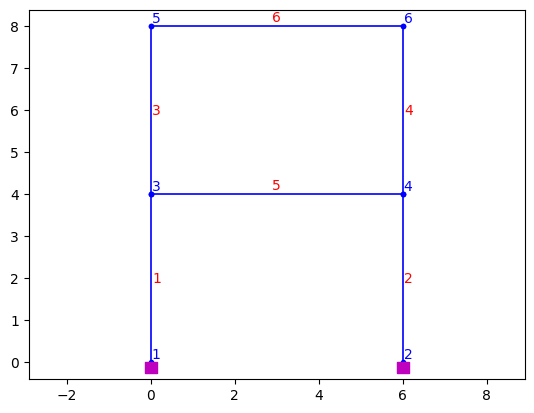

In [13]:
trans_Col_Tag=1
trans_Viga_Tag=2

geomTransf('Linear',trans_Col_Tag)
geomTransf('Linear',trans_Viga_Tag)

#Columnas
element('elasticBeamColumn', 1, 1, 3, A_col*1e6,Es, I_col, trans_Col_Tag) # Col 1P Izq
element('elasticBeamColumn', 2, 2, 4, A_col*1e6, Es, I_col, trans_Col_Tag) # Col 1P Der
element('elasticBeamColumn', 3, 3, 5, A_col*1e6, Es, I_col, trans_Col_Tag) # Col 2P Izq
element('elasticBeamColumn', 4, 4, 6, A_col*1e6, Es, I_col, trans_Col_Tag) # Col 2P Der

#Vigas
element('elasticBeamColumn', 5, 3, 4, A_viga, Es, I_viga*1e6, trans_Viga_Tag) # Viga 1P
element('elasticBeamColumn', 6, 5, 6, A_viga, Es, I_viga*1e6, trans_Viga_Tag) # Viga Techo

opsv.plot_model()

7. Aplicación de cargas:

    Se aplicará una carga estática muerta sobreimpuesta de 5kN/m sobre las vigas. Tambien se asignara una masa traslacional sobre los nodos para el análisis sísmico de 1 ton.


Para iniciar cualquier análisis se debe crear una serie de tiempo, en la cual el tiempo cero contiene todo el análisis de cargas estáticas.

<Axes: >

<Figure size 640x480 with 0 Axes>

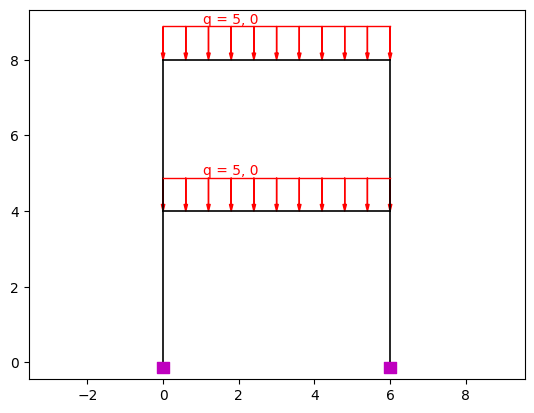

In [14]:
#ASIGNACIÓN DE CARGAS SOBREIMPUESTAS
timeSeries('Linear',1)
pattern('Plain',1,1)

vigas=[5,6] #Tags de los elementos viga
wviga=5 #kN valor de carga distribuida sobre la viga
eleLoad('-ele',*vigas,'-type','beamUniform',-wviga)

#ASIGACION DE MASA EN LOS NODOS

mass(3,1,1,0)
mass(4,1,1,0)
mass(5,1,1,0)
mass(6,1,1,0)

plt.figure() #figura del modelo con cargas
opsv.plot_load()

8. Análisis estático:

En primer lugar se ejecuta el análisis estático o de cargas de gravedad, para lo cual se utilizará la libreria de opseestools. 

In [15]:
import opseestools.analisis as an
import opseestools.utilidades as ut

an.gravedad()

# Es fundamental reiniciar el tiempo a 0 luego del análisis de gravedad, para fijar la aplicación de cargas estáticas solo en el primer paso
loadConst('-time',0.0) 

9. Cálculo del periodo fundamental

Periodos: T1=0.24s, T2=0.09s


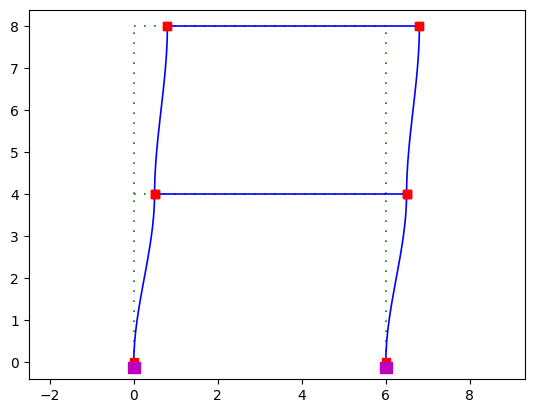

In [16]:
eig=eigen(2) #calcula las frecuencias de la canitdad de modos indicada, en este caso dos.
T1=2*3.1416/np.sqrt(eig[0])
T2=2*3.1416/np.sqrt(eig[1])
print(f"Periodos: T1={T1:.2f}s, T2={T2:.2f}s")

opsv.plot_mode_shape(1) #para graficar el modo 1

10. Cargar el Registro sismico:

    Para cargar el registro sismico se debe conocer cuantos datos tiene, cual es el intervalo o paso de tiempo entre cada dato y, en qué unidades está la aceleración (usualmente estan en unidades de g, la gravedad)

In [17]:
xi=0.05  # 5% de amortiguamiento

#Se extraen las frecuencias angulares de los dos únicos modos del sistema
wn1=np.sqrt(eig[0])
wn2=np.sqrt(eig[1])

# Cálculo de coeficientes de Rayleigh (Masa y Rigidez Inicial)
a0=xi * (2.0 * wn1 * wn2) / (wn1 + wn2)
a1=xi * 2.0 / (wn1 + wn2)

# Asignación en OpenSees: rayleigh(alphaM, betaKcurr, betaKinit, betaKcomm)
# Usaremos la rigidez inicial (betaKinit = a1)
rayleigh(a0, 0.0, a1, 0.0)


wipeAnalysis()

dt=0.01
npts=3000
g=9.81 # m/s2 (Factor de escala para pasar de fracciones de g a aceleración)



Análisis dinámico

In [18]:
# Serie de tiempo leyendo el archivo txt
timeSeries('Path', 2, '-filePath', 'Sismo1.txt', '-dt', dt, '-factor', g)

# Patrón de carga de excitación en la base (Dirección 1 = X)
pattern('UniformExcitation', 2, 1, '-accel', 2)

#Análisis dinámico
constraints('Transformation') # Necesario por el uso de equalDOF
numberer('RCM')
system('BandGeneral')
test('NormDispIncr', 1.0e-8, 10, 0) # Tolerancia estricta
algorithm('Newton')
integrator('Newmark', 0.5, 0.25)    # Aceleración promedio (Incondicionalmente estable)
analysis('Transient')


#iniciar variables de salida

time_out = np.zeros(npts)
disp_techo = np.zeros(npts)
disp_entrepiso = np.zeros(npts)
deriva_techo = np.zeros(npts)
fuerzas_col1=np.zeros(npts)
fuerzas_viga5=np.zeros(npts)
max_disp_4 = 0.0
max_disp_6 = 0.0
max_f_axial_col1=0.0

#CALCULO DE LOS DESPLAZAMIENTOS, DERIVAS Y FUERZAS
h_piso2 = y2 - y1 # Altura del segundo piso (4.0 m)

for i in range(npts):
    ok = analyze(1, dt)
    if ok != 0:
        print(f"El análisis falló en el paso {i}, t = {getTime():.2f} s")
        break
    
    time_out[i] = getTime() #tiempo actual
    
    # Extraer desplazamientos en X (GDL 1) de los nodos 6 (Techo) y 4 (Piso 1)
    u_techo = nodeDisp(6, 1)
    u_piso1 = nodeDisp(4, 1)

    #Extraer fuerzas
    f_col1 = eleForce(1)
    f_viga5 = eleForce(5)
    
    # Almacenar desplazamiento total del techo
    disp_techo[i] = u_techo
    disp_entrepiso[i] = u_piso1
    fuerzas_col1[i]= f_col1[0] #fuerza axial
    fuerzas_viga5[i] = f_viga5[2] #momento flector


    # Calcular y almacenar la deriva del techo (Drift del piso 2)
    deriva_techo[i] = (u_techo - u_piso1) / h_piso2
    
    # Actualizar máximos absolutos
    if abs(u_piso1) > max_disp_4:
        max_disp_4 = abs(u_piso1)
    if abs(u_techo) > max_disp_6:
        max_disp_6 = abs(u_techo)
    if abs(f_col1[0]) > max_f_axial_col1:
        max_f_axial_col1 = abs(f_col1[0])

print("Análisis dinámico completado con éxito.")



Análisis dinámico completado con éxito.


12. Visualización de resultados

Desplazamiento Máximo Nudo 4 (Piso 1): 0.00813 m
Desplazamiento Máximo Nudo 6 (Piso 2): 0.01301 m
Fuerza Axial Máxima en la base (Columna 1): 14.98 kN


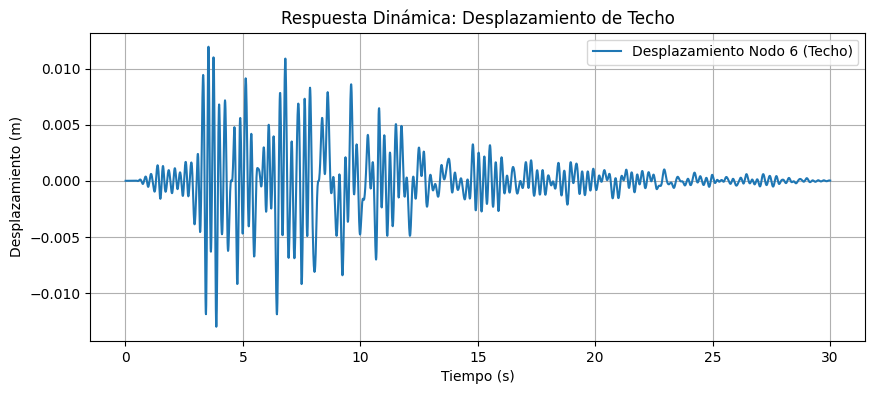

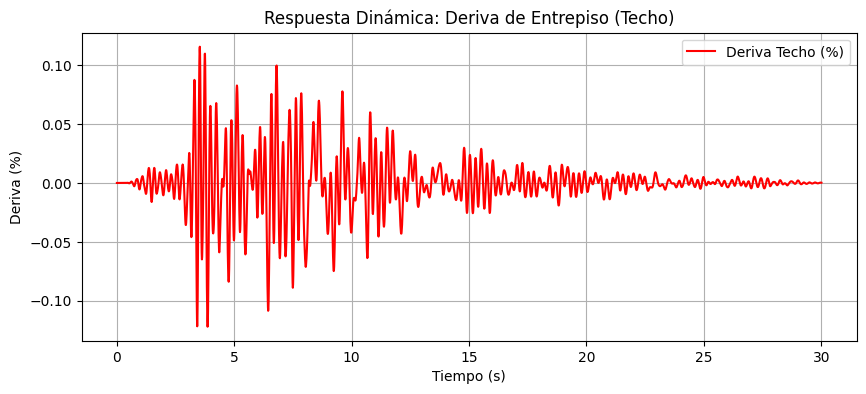

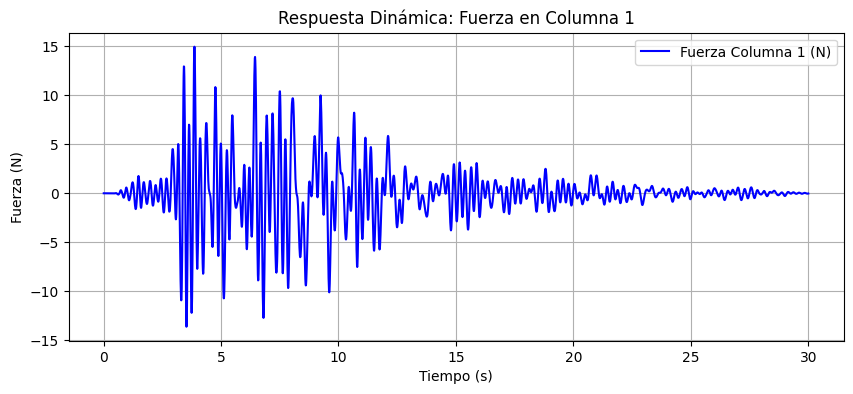

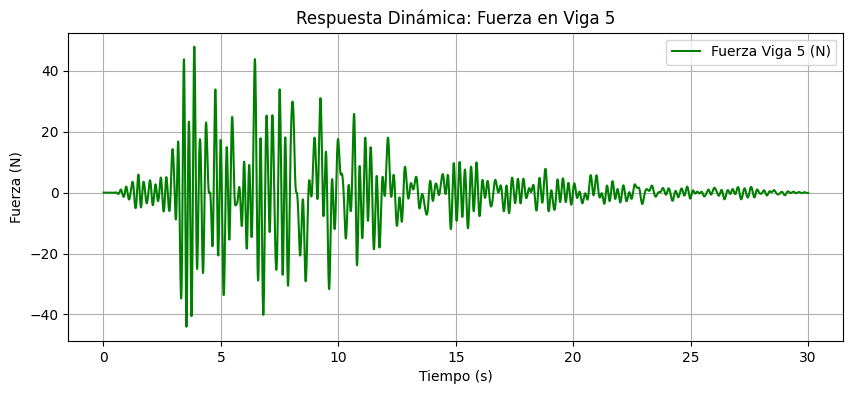

1

In [19]:
#DESPLAZAMIENTO MÁXIMO DE LOS NODOS 4 Y 6
print(f"Desplazamiento Máximo Nudo 4 (Piso 1): {max_disp_4:.5f} m")
print(f"Desplazamiento Máximo Nudo 6 (Piso 2): {max_disp_6:.5f} m")
print(f"Fuerza Axial Máxima en la base (Columna 1): {max_f_axial_col1:.2f} kN")


#DESPLAZAMIENTOS DE TECHO EN EL TIEMPO
plt.figure(figsize=(10, 4))
plt.plot(time_out, disp_techo, label='Desplazamiento Nodo 6 (Techo)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Desplazamiento (m)')
plt.title('Respuesta Dinámica: Desplazamiento de Techo')
plt.grid(True)
plt.legend()
plt.show()

#DERIVA DE TECHO EN EL TIEMPO
plt.figure(figsize=(10, 4))
plt.plot(time_out, deriva_techo * 100, color='red', label='Deriva Techo (%)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Deriva (%)')
plt.title('Respuesta Dinámica: Deriva de Entrepiso (Techo)')
plt.grid(True)
plt.legend()
plt.show()

#FUERZA AXIAL COLUMNA 1 EN EL TIEMPO

plt.figure(figsize=(10, 4))
plt.plot(time_out, fuerzas_col1, color='blue', label='Fuerza Columna 1 (N)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Fuerza (N)')
plt.title('Respuesta Dinámica: Fuerza en Columna 1')
plt.grid(True)
plt.legend()
plt.show()

#FUERZA VIGA 5 EN EL TIEMPO
plt.figure(figsize=(10, 4))
plt.plot(time_out, fuerzas_viga5, color='green', label='Fuerza Viga 5 (N)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Fuerza (N)')
plt.title('Respuesta Dinámica: Fuerza en Viga 5')
plt.grid(True)
plt.legend()
plt.show()

#EXTRACCIÓN DE FUERZAS EN ELEMENTOS
recorder('Element', '-file', 'Fuerzas_Columnas_Piso1.txt', '-time', '-ele', 1, 2, 'localForce')
recorder('Element', '-file', 'Fuerzas_Vigas.txt', '-time', '-ele', 5, 6, 'localForce')